# Regression logistique — classification de tumeurs

> **Objectif :** Prédire si une tumeur est maligne ou bénigne à partir de
> 30 caractéristiques biologiques mesurées sur des cellules.
> On compare notre implémentation à `LogisticRegression` de scikit-learn.

---
**Dataset :** Breast Cancer Wisconsin (sklearn)
**Algorithme :** Régression logistique (descente de gradient)
**Learning rate :** 0.01 — **Itérations :** 1000

## 1. Imports et dépendances

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as LR_sklearn
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score,
                             precision_score, recall_score)

from LogReg import LogisticRegression   # Our implementation

## 2. Chargement et exploration des données

Le dataset Breast Cancer Wisconsin contient 569 observations et 30 features
numériques (rayon, texture, périmètre, aire, etc.) calculées à partir d'images
de biopsies. La cible est binaire : 0 = malin, 1 = bénin.

In [2]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

df = pd.DataFrame(X, columns=bc.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Shape :", X.shape)
print("Classes :", bc.target_names)
print()
print("Distribution de la cible :")
print(pd.Series(y).value_counts().rename({0: "Malignant", 1: "Benign"}))

Shape : (569, 30)
Classes : ['malignant' 'benign']

Distribution de la cible :
Benign       357
Malignant    212
Name: count, dtype: int64


## 3. Prétraitement

La régression logistique avec descente de gradient est sensible aux échelles.
On standardise les features (moyenne 0, écart-type 1) en ajustant le scaler
**uniquement sur le train** pour éviter toute fuite d'information vers le test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)          # transform uniquement, pas fit_transform

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

Train : (455, 30)  |  Test : (114, 30)


## 4. Regression logistique — notre implémentation

Descente de gradient batch sur 1000 itérations avec lr=0.01.

In [5]:
model_custom = LogisticRegression(lr=0.01, n_iters=1000)

start = time.time()
model_custom.fit(X_train, y_train)
t_train_custom = time.time() - start

start = time.time()
y_pred_custom = model_custom.predict(X_test)
t_pred_custom = time.time() - start

print(f"Temps entraînement : {t_train_custom:.4f} s")
print(f"Temps prédiction   : {t_pred_custom:.4f} s")

Temps entraînement : 0.0392 s
Temps prédiction   : 0.0001 s


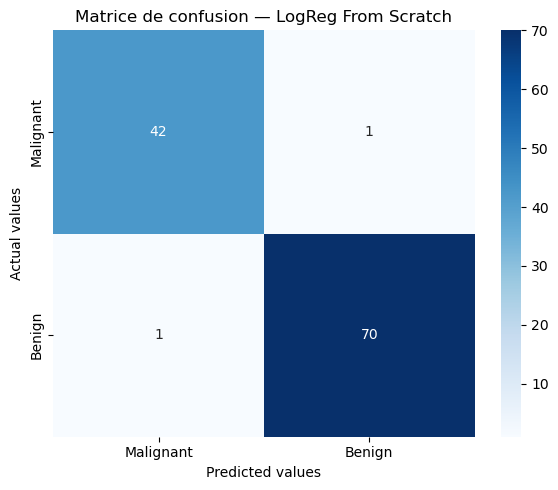

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        43
      Benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title("Matrice de confusion — LogReg From Scratch")
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_custom,
                             target_names=['Malignant', 'Benign']))

## 5. Regression logistique — scikit-learn (référence)

sklearn utilise par défaut le solveur `lbfgs`, plus efficace que la descente
de gradient batch pour ce type de problème.

In [7]:
model_sklearn = LR_sklearn(max_iter=1000, random_state=42)

start = time.time()
model_sklearn.fit(X_train, y_train)
t_train_sklearn = time.time() - start

start = time.time()
y_pred_sklearn = model_sklearn.predict(X_test)
t_pred_sklearn = time.time() - start

print(f"Temps entraînement : {t_train_sklearn:.4f} s")
print(f"Temps prédiction   : {t_pred_sklearn:.4f} s")

Temps entraînement : 0.0206 s
Temps prédiction   : 0.0009 s


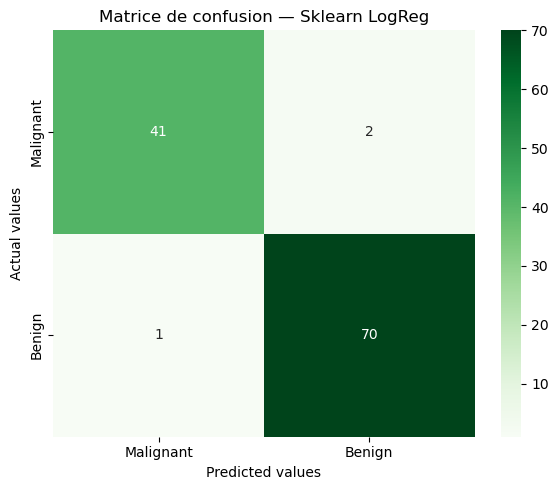

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [8]:
cm2 = confusion_matrix(y_test, y_pred_sklearn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title("Matrice de confusion — Sklearn LogReg")
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_sklearn,
                             target_names=['Malignant', 'Benign']))

## 6. Tableau de benchmark

In [9]:
def get_metrics(y_true, y_pred, t_train, t_pred):
    return {
        "Accuracy"        : round(accuracy_score(y_true, y_pred), 4),
        "Precision"       : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"          : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score"        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Temps train (s)" : round(t_train, 4),
        "Temps pred (s)"  : round(t_pred, 4),
    }

results = {
    "LogReg From Scratch"  : get_metrics(y_test, y_pred_custom,  t_train_custom,  t_pred_custom),
    "Sklearn LogReg": get_metrics(y_test, y_pred_sklearn, t_train_sklearn, t_pred_sklearn),
}

benchmark_df = pd.DataFrame(results).T
benchmark_df.index.name = "Modèle"
print("=" * 65)
print("      BENCHMARK — Régression Logistique (Breast Cancer)")
print("=" * 65)
print(benchmark_df.to_string())
print("=" * 65)
benchmark_df

      BENCHMARK — Régression Logistique (Breast Cancer)
                     Accuracy  Precision  Recall  F1-Score  Temps train (s)  Temps pred (s)
Modèle                                                                                     
LogReg From Scratch    0.9825     0.9859  0.9859    0.9859           0.0392          0.0001
Sklearn LogReg         0.9737     0.9722  0.9859    0.9790           0.0206          0.0009


,Accuracy,Precision,Recall,F1-Score,Temps train (s),Temps pred (s)
Modèle,,,,,,
LogReg From Scratch,0.9825,0.9859,0.9859,0.9859,0.0392,0.0001
Sklearn LogReg,0.9737,0.9722,0.9859,0.9790,0.0206,0.0009


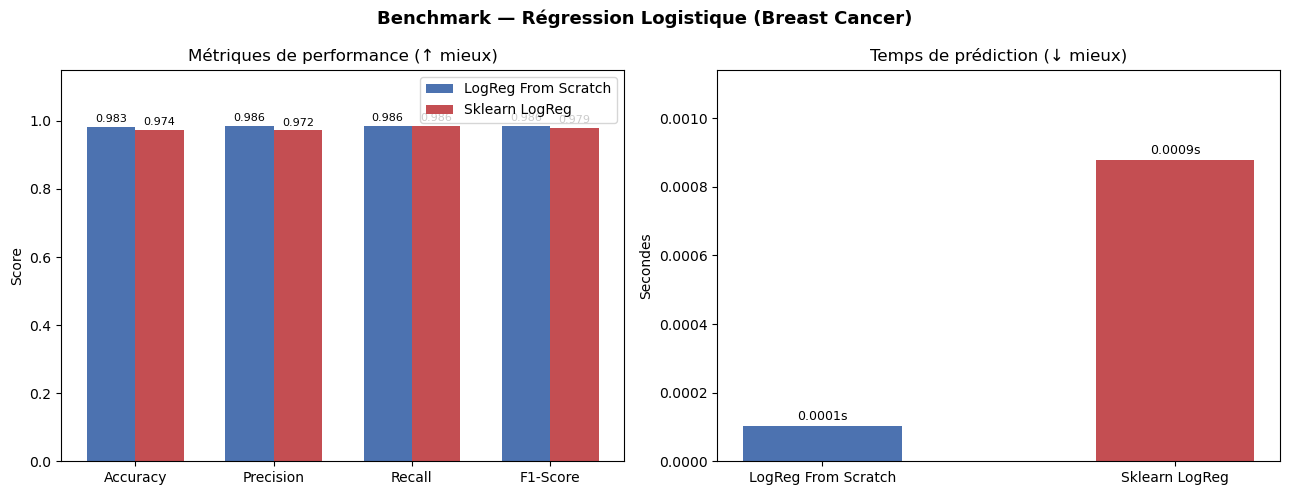

In [10]:
# Graphique métriques de performance
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x      = np.arange(len(metrics))
width  = 0.35
colors = ["#4C72B0", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Métriques —
bars1 = axes[0].bar(x - width/2,
                    [benchmark_df.loc["LogReg From Scratch",   m] for m in metrics],
                    width, label="LogReg From Scratch",   color=colors[0])
bars2 = axes[0].bar(x + width/2,
                    [benchmark_df.loc["Sklearn LogReg", m] for m in metrics],
                    width, label="Sklearn LogReg", color=colors[1])
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].set_title("Métriques de performance (↑ mieux)")
axes[0].legend()
axes[0].bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
axes[0].bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)

# — Temps de prédiction —
t_vals = [t_pred_custom, t_pred_sklearn]
labels = ["LogReg From Scratch", "Sklearn LogReg"]
bars3 = axes[1].bar(labels, t_vals, color=colors, width=0.45)
axes[1].set_title("Temps de prédiction (↓ mieux)")
axes[1].set_ylabel("Secondes")
axes[1].set_ylim(0, max(t_vals) * 1.3)
for bar, val in zip(bars3, t_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(t_vals)*0.02,
                 f"{val:.4f}s", ha='center', fontsize=9)

plt.suptitle("Benchmark — Régression Logistique (Breast Cancer)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Courbe d'apprentissage

On visualise l'évolution de la loss (binary cross-entropy) au fil des itérations
pour vérifier que le modèle converge correctement.

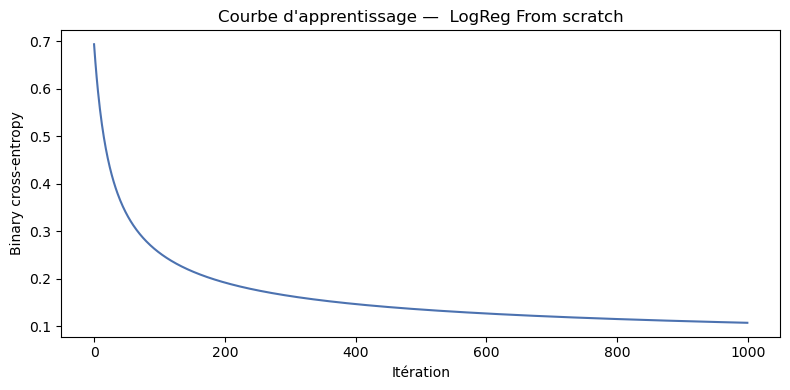

In [11]:
class LogisticRegressionVerbose(LogisticRegression):
    """Variante qui enregistre la loss à chaque itération."""
    def fit(self, X, y):
        from LogReg import sigmoid
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.biais   = 0
        self.losses  = []

        for _ in range(self.n_iters):
            linear_pred = np.dot(X, self.weights) + self.biais
            predictions = sigmoid(linear_pred)

            # Binary cross-entropy
            eps = 1e-15
            loss = -np.mean(y * np.log(predictions + eps)
                            + (1 - y) * np.log(1 - predictions + eps))
            self.losses.append(loss)

            error = predictions - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            self.weights -= self.lr * dw
            self.biais   -= self.lr * db
        return self

model_verbose = LogisticRegressionVerbose(lr=0.01, n_iters=1000)
model_verbose.fit(X_train, y_train)

plt.figure(figsize=(8, 4))
plt.plot(model_verbose.losses, color="#4C72B0", linewidth=1.5)
plt.xlabel("Itération")
plt.ylabel("Binary cross-entropy")
plt.title("Courbe d'apprentissage —  LogReg From scratch")
plt.tight_layout()
plt.show()